# **Rudimentary fire detection algorithm for the VIIRS sensor onboard Suomi-NPP satellite**

#### **Description:** 
This notebook aims to detect active fire hotspots from remote sensing thermal anomaly in netCDF using simple thresholding method. Here sample data **VNP02MOD_NRT.A2020234.2100.001** and **VNP03MOD_NRT.A2020234.2100.001** are used. The workflow can be divided into the following steps:

<br>

**1) Reading netCDF file and Dataset generation**

**2) Data pre-processing, first visualization and exploration**

**3) Thershold generation and mask creation**

**4) Extracting geolocation**

**5) Vector cluster generation**

**6) Writing outputs**

<br>

***

**Data Source:** Visible Infrared Imaging Radiometer Suite (VIIRS) I-Band 375 m Active Fire Data

**Date:** 01.11.2021

**Author:** Ka-Hei, Chow

## **Set Up environment**

Install and import required libraries

In [1]:
# Local run: dependencies are installed in the active Python environment.
# Original Colab pip install commands were removed to keep full-notebook execution clean.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
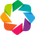

In [2]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from skimage.filters import threshold_otsu
import folium
from bokeh.plotting import show
from sklearn.datasets import make_blobs
import holoviews as hv
from holoviews import dim, opts
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from sklearn.cluster import KMeans
import cv2 as cv
from matplotlib import cm

%matplotlib inline
hv.extension('bokeh')

Define options for display

In [3]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

Connect to google drive

In [4]:
# Local run: files are read from the project folder, so Google Drive mounting is not needed.


## **Data Import**

As data (M13 band) and coordinates are stored in different netCDF files, both files are imported to merge the information for a new xarray dataset.

In [1]:
data_path = r'data/VNP02MOD.A2023100.0648.002.2023100141336.nc'
coords_path = r'data/VNP03MOD.A2023100.0648.002.2023100135443.nc'

obs_ds = xr.open_dataset(data_path, group='/observation_data')
obs_ds


NameError: name 'xr' is not defined

In the observation, there are no coordinates values so it need to be assigned.

In [6]:
obs_ds.coords

Coordinates:
    *empty*

Where the coordinates are stored.

In [7]:
coords_ds = xr.open_dataset(coords_path, group='/geolocation_data')
coords_ds

<xarray.Dataset> Size: 424MB
Dimensions:          (number_of_lines: 3232, number_of_pixels: 3200)
Dimensions without coordinates: number_of_lines, number_of_pixels
Data variables:
    latitude         (number_of_lines, number_of_pixels) float32 41MB ...
    longitude        (number_of_lines, number_of_pixels) float32 41MB ...
    height           (number_of_lines, number_of_pixels) float32 41MB ...
    range            (number_of_lines, number_of_pixels) float32 41MB ...
    sensor_azimuth   (number_of_lines, number_of_pixels) float32 41MB ...
    sensor_zenith    (number_of_lines, number_of_pixels) float32 41MB ...
    solar_azimuth    (number_of_lines, number_of_pixels) float32 41MB ...
    solar_zenith     (number_of_lines, number_of_pixels) float32 41MB ...
    land_water_mask  (number_of_lines, number_of_pixels) float32 41MB ...
    water_present    (number_of_lines, number_of_pixels) float32 41MB ...
    quality_flag     (number_of_lines, number_of_pixels) uint8 10MB ...

Save the coordinates.

In [8]:
min_lat = np.min(coords_ds.latitude)
max_lat = np.max(coords_ds.latitude)

min_lon = np.min(coords_ds.longitude)
max_lon = np.max(coords_ds.longitude)

Assign coordinates.

In [9]:
obs_ds = obs_ds.assign_coords(latitude = coords_ds.latitude, longitude = coords_ds.longitude)

Before merging all the data variables and coordinates, it need to be checked if the shapes for all information are identical.

In [10]:
cols = [obs_ds.M13,obs_ds.M13_quality_flags,coords_ds.height,coords_ds.land_water_mask,obs_ds.longitude,obs_ds.latitude.values]

if all(x.shape[0]==cols[0].values.shape[0] for x in cols) == True:
  print("All columns have the same shape of {}.".format(obs_ds.M13.values.shape))

All columns have the same shape of (3232, 3200).


Using all provided information, a new xarray dataset can be generated with relevant data variables.

In [11]:
ds = xr.Dataset(
    data_vars=dict(
        M13=(["y", "x"], obs_ds.M13.values),
        M13_flags=(["y", "x"], obs_ds.M13_quality_flags.values),
        elev=(["y", "x"], coords_ds.height.values),
        mask=(["y", "x"], coords_ds.land_water_mask.values)
    ),
    coords=dict(
        lon=(["y", "x"], obs_ds.longitude.values),
        lat=(["y", "x"], obs_ds.latitude.values)
    ),
    attrs=dict(description="VIIRS Active Fire Detection Data.")
)

In [12]:
ds

<xarray.Dataset> Size: 269MB
Dimensions:    (y: 3232, x: 3200)
Coordinates:
    lon        (y, x) float32 41MB 43.4 43.42 43.43 43.45 ... 76.38 76.41 76.43
    lat        (y, x) float32 41MB -30.62 -30.62 -30.63 ... -56.35 -56.35 -56.35
Dimensions without coordinates: y, x
Data variables:
    M13        (y, x) float64 83MB 530.0 530.0 530.0 530.0 ... 530.0 530.0 530.0
    M13_flags  (y, x) uint16 21MB 256 256 256 256 256 ... 256 256 256 256 256
    elev       (y, x) float32 41MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    mask       (y, x) float32 41MB 7.0 7.0 7.0 7.0 7.0 ... 7.0 7.0 7.0 7.0 7.0
Attributes:
    description:  VIIRS Active Fire Detection Data.

## **First Visualization and Data Pre-processing**

Before thresholding is applied, data visualization is needed in order to explore the dataset for necessary pre-processing/ data cleaning steps. It can be seen that the yellow stripes generate outliners (extreme high values) in the dataset.

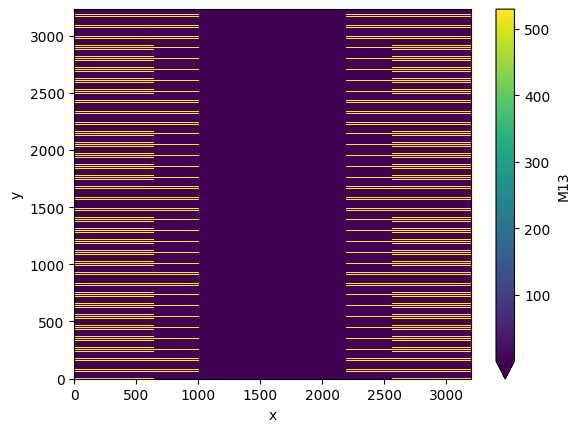

In [13]:
ds.M13.plot(robust=True)

In [14]:
arr = ds.M13.values.astype('float64').copy()
arr[(arr <= 0) | (arr > 100)] = np.nan


By checking the histopgram, the distribution of data values can be better understood. Most of the useful values are under 100 while the stripes produce values over 500, causing another two peaks.

(array([[195., 412., 257., ...,  61.,   0.,   0.],
        [192., 412., 266., ...,  56.,   0.,   0.],
        [204., 375., 288., ...,  61.,   0.,   0.],
        ...,
        [197., 479., 692., ...,   0.,   0.,   0.],
        [211., 454., 704., ...,   0.,   0.,   0.],
        [238., 449., 698., ...,   0.,   0.,   0.]], shape=(3200, 10)),
 array([0.00108056, 0.05494268, 0.10880479, 0.16266691, 0.21652903,
        0.27039115, 0.32425326, 0.37811538, 0.4319775 , 0.48583962,
        0.53970173]),
 <a list of 3200 BarContainer objects>)

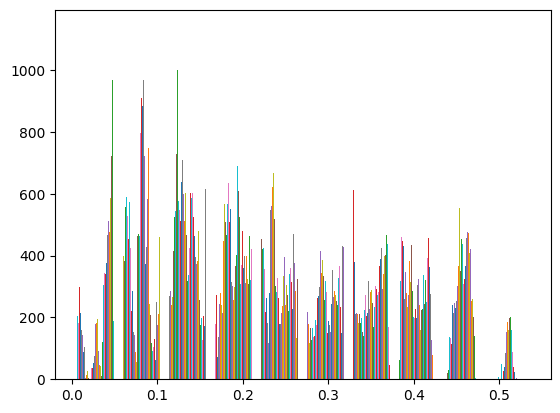

In [15]:
plt.hist(arr)

In order to clean the outliers, all values above 5 standard deviation of median are removed, by replacing the values with missing values (np.nan).

In [16]:
raw_arr = arr.copy()
d = np.abs(arr - np.nanmedian(arr))
mdev = np.nanmedian(d)
s = d / mdev if mdev else np.zeros_like(arr)
arr[s < 5] = np.nan

if not np.isfinite(arr).any():
    arr = raw_arr


Check if the outliers are replaced by nan.

In [17]:
new_arr = arr
new_arr

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [0.36016134, 0.389276  , 0.39089348, ..., 0.24046775, 0.20973561,
        0.2194405 ],
       ...,
       [0.12077415, 0.12400912, 0.1256266 , ..., 0.13209652, 0.13047904,
        0.13047904],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(3232, 3200))

(array([[195., 412., 257., ...,  61.,   0.,   0.],
        [192., 412., 266., ...,  56.,   0.,   0.],
        [204., 375., 288., ...,  61.,   0.,   0.],
        ...,
        [197., 479., 692., ...,   0.,   0.,   0.],
        [211., 454., 704., ...,   0.,   0.,   0.],
        [238., 449., 698., ...,   0.,   0.,   0.]], shape=(3200, 10)),
 array([0.00108056, 0.05494268, 0.10880479, 0.16266691, 0.21652903,
        0.27039115, 0.32425326, 0.37811538, 0.4319775 , 0.48583962,
        0.53970173]),
 <a list of 3200 BarContainer objects>)

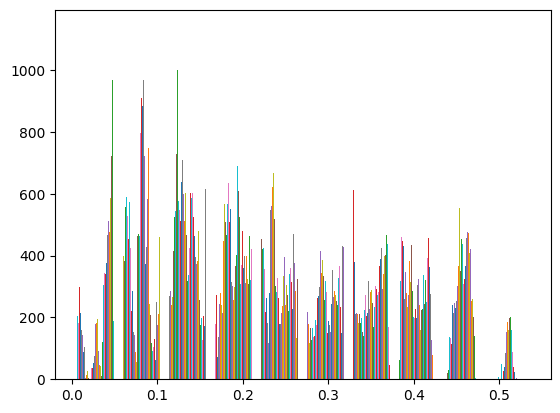

In [18]:
plt.hist(new_arr)

To better explore the dataset, descriptive statistics are calculated. It can be seen that the differences between min and max values are in the power of tens so logarithmic transformation would be helpful to manipulate the data values.

In [19]:
df_describe = pd.DataFrame(new_arr.flatten())
df_describe.describe()

,0
count,9010816.000
mean,0.230
std,0.133
min,0.001
25%,0.121
50%,0.211
75%,0.341
max,0.540


In [20]:
log_arr = np.log(new_arr)
finite_log = np.isfinite(log_arr)
hot_y, hot_x = np.unravel_index(np.nanargmax(log_arr), log_arr.shape)
roi_y = slice(max(0, hot_y - 50), min(log_arr.shape[0], hot_y + 50))
roi_x = slice(max(0, hot_x - 50), min(log_arr.shape[1], hot_x + 50))


In logarithmic scale, the data values are more nicely distributed.

(array([[  0.,   0.,   0., ..., 355., 728., 849.],
        [  0.,   0.,   0., ..., 363., 708., 868.],
        [  0.,   0.,   0., ..., 359., 719., 860.],
        ...,
        [  0.,   0.,   0., ..., 887., 989., 135.],
        [  0.,   0.,   0., ..., 872., 989., 122.],
        [  0.,   0.,   0., ..., 897., 972., 120.]], shape=(3200, 10)),
 array([-6.83027582, -6.20892211, -5.58756839, -4.96621467, -4.34486095,
        -3.72350723, -3.10215351, -2.48079979, -1.85944608, -1.23809236,
        -0.61673864]),
 <a list of 3200 BarContainer objects>)

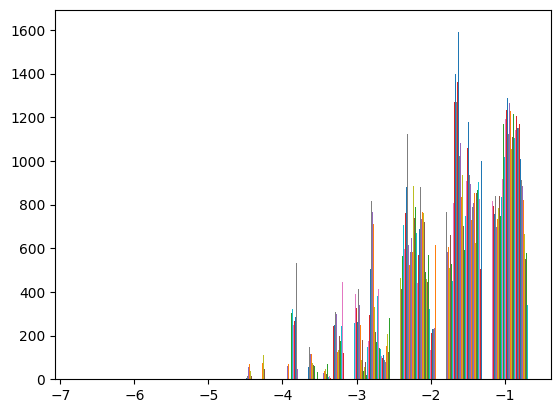

In [21]:
plt.hist(log_arr)

Look at the descriptive statistics again. It can be seen that the differences between max and min are much smaller.

In [22]:
df_describe = pd.DataFrame(log_arr.flatten())
df_describe.describe()

,0
count,9010816.000
mean,-1.700
std,0.769
min,-6.830
25%,-2.114
50%,-1.554
75%,-1.077
max,-0.617


First visualization of the M13 band.

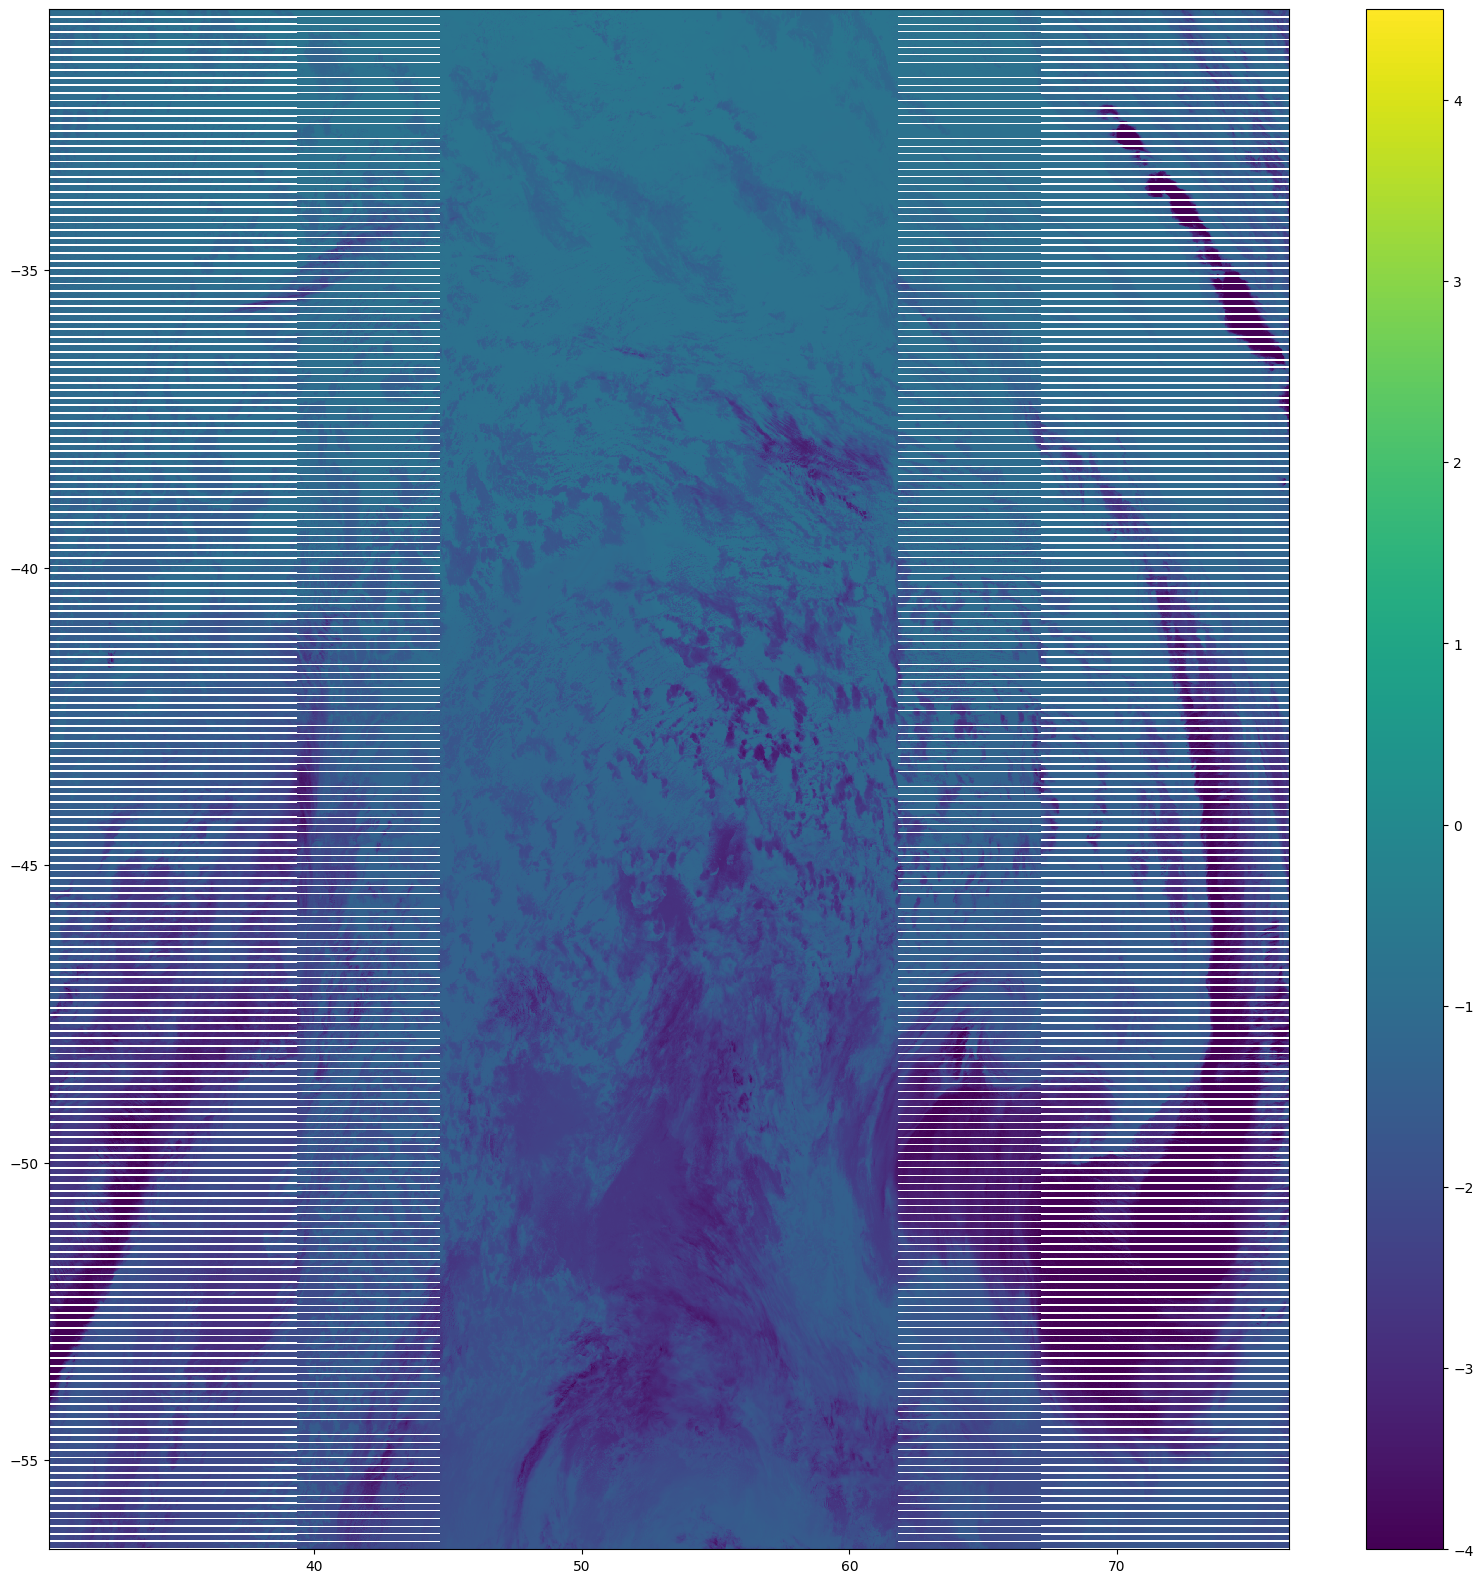

In [23]:
plt.figure(figsize = (20,20))
plt.imshow(log_arr, interpolation='nearest', aspect='auto', vmin=-4, vmax=4.5, extent=(min_lon,max_lon,min_lat,max_lat))
plt.colorbar()

When zoom in, some hotspots can be seen in yellow color.

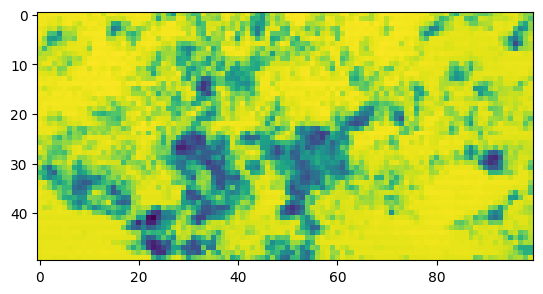

In [24]:
plt.imshow(log_arr[roi_y, roi_x])

In order to better checking out the data, holoviews is used so panning and zooming are possible when viewing the data.

In [25]:
img = hv.Image(log_arr[roi_y, roi_x])
img.opts(frame_width=500, frame_height=500, colorbar=True, axiswise=True, cmap="fire")

:Image   [x,y]   (z)

In [26]:
show(hv.render(img))

In [27]:
log_arr.shape

(3232, 3200)

Add M13 in log scale into another data variable of the xarray dataset.

In [28]:
ds["M13_log"]=(['y', 'x'], log_arr)
ds

<xarray.Dataset> Size: 352MB
Dimensions:    (y: 3232, x: 3200)
Coordinates:
    lon        (y, x) float32 41MB 43.4 43.42 43.43 43.45 ... 76.38 76.41 76.43
    lat        (y, x) float32 41MB -30.62 -30.62 -30.63 ... -56.35 -56.35 -56.35
Dimensions without coordinates: y, x
Data variables:
    M13        (y, x) float64 83MB 530.0 530.0 530.0 530.0 ... 530.0 530.0 530.0
    M13_flags  (y, x) uint16 21MB 256 256 256 256 256 ... 256 256 256 256 256
    elev       (y, x) float32 41MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    mask       (y, x) float32 41MB 7.0 7.0 7.0 7.0 7.0 ... 7.0 7.0 7.0 7.0 7.0
    M13_log    (y, x) float64 83MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    description:  VIIRS Active Fire Detection Data.

In order to better compare the data values and topography, the data are overlaid on the base map using folium.

In [29]:
def to_map(df,zoom=6):
    """
    Display band on an interactive map.
    Description
    ----------
    Display xarray.Dataset in a folium map with multiple basemap options.
    Parameters
    ----------
    df: xarray.Dataset
        dataset with single time step, including bands "M13".
    Returns
    -------
    map: Folium Map
        Folium map with single band displayed as images with layer control.
    """

    #error catching
    assert isinstance(df, xr.Dataset),"Input has to be a xarray.Dataset."
    
    band = df.M13_log.values
      
    #boundary of the image on the map
    min_lon = df.lon.min().values.astype(float) + 0.0
    max_lon = df.lon.max().values.astype(float) + 0.0
    min_lat = df.lat.min().values.astype(float) + 0.0
    max_lat = df.lat.max().values.astype(float) + 0.0
    
    #create basemap for folium
    basemaps = {
        'Google Satellite': folium.TileLayer(
            tiles = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
            attr = 'Google',
            name = 'Basemap: Google Satellite',
            overlay = True,
            control = True
        ),
        'Google Terrain': folium.TileLayer(
            tiles = 'https://mt1.google.com/vt/lyrs=p&x={x}&y={y}&z={z}',
            attr = 'Google',
            name = 'Basemap: Google Terrain',
            overlay = True,
            control = True
        )
    }
    
    #display layers on map
    map_ = folium.Map(location=[(min_lat+max_lat)/2, (min_lon+max_lon)/2], zoom_start = zoom)
    basemaps['Google Satellite'].add_to(map_)
    basemaps['Google Terrain'].add_to(map_)

    factor = len(df.lat)*len(df.lon)/5000000
    img = cv.resize(np.flipud(np.fliplr(band.astype('float32'))), 
                         dsize=(math.ceil(len(df.lat)/factor), 
                                math.ceil(len(df.lon)/factor)), 
                         interpolation=cv.INTER_CUBIC)

    folium.raster_layers.ImageOverlay(
        img,[[min_lat, min_lon], [max_lat, max_lon]], name='image',colormap=cm.viridis
        ).add_to(map_)
  
    folium.LayerControl().add_to(map_)
    return map_


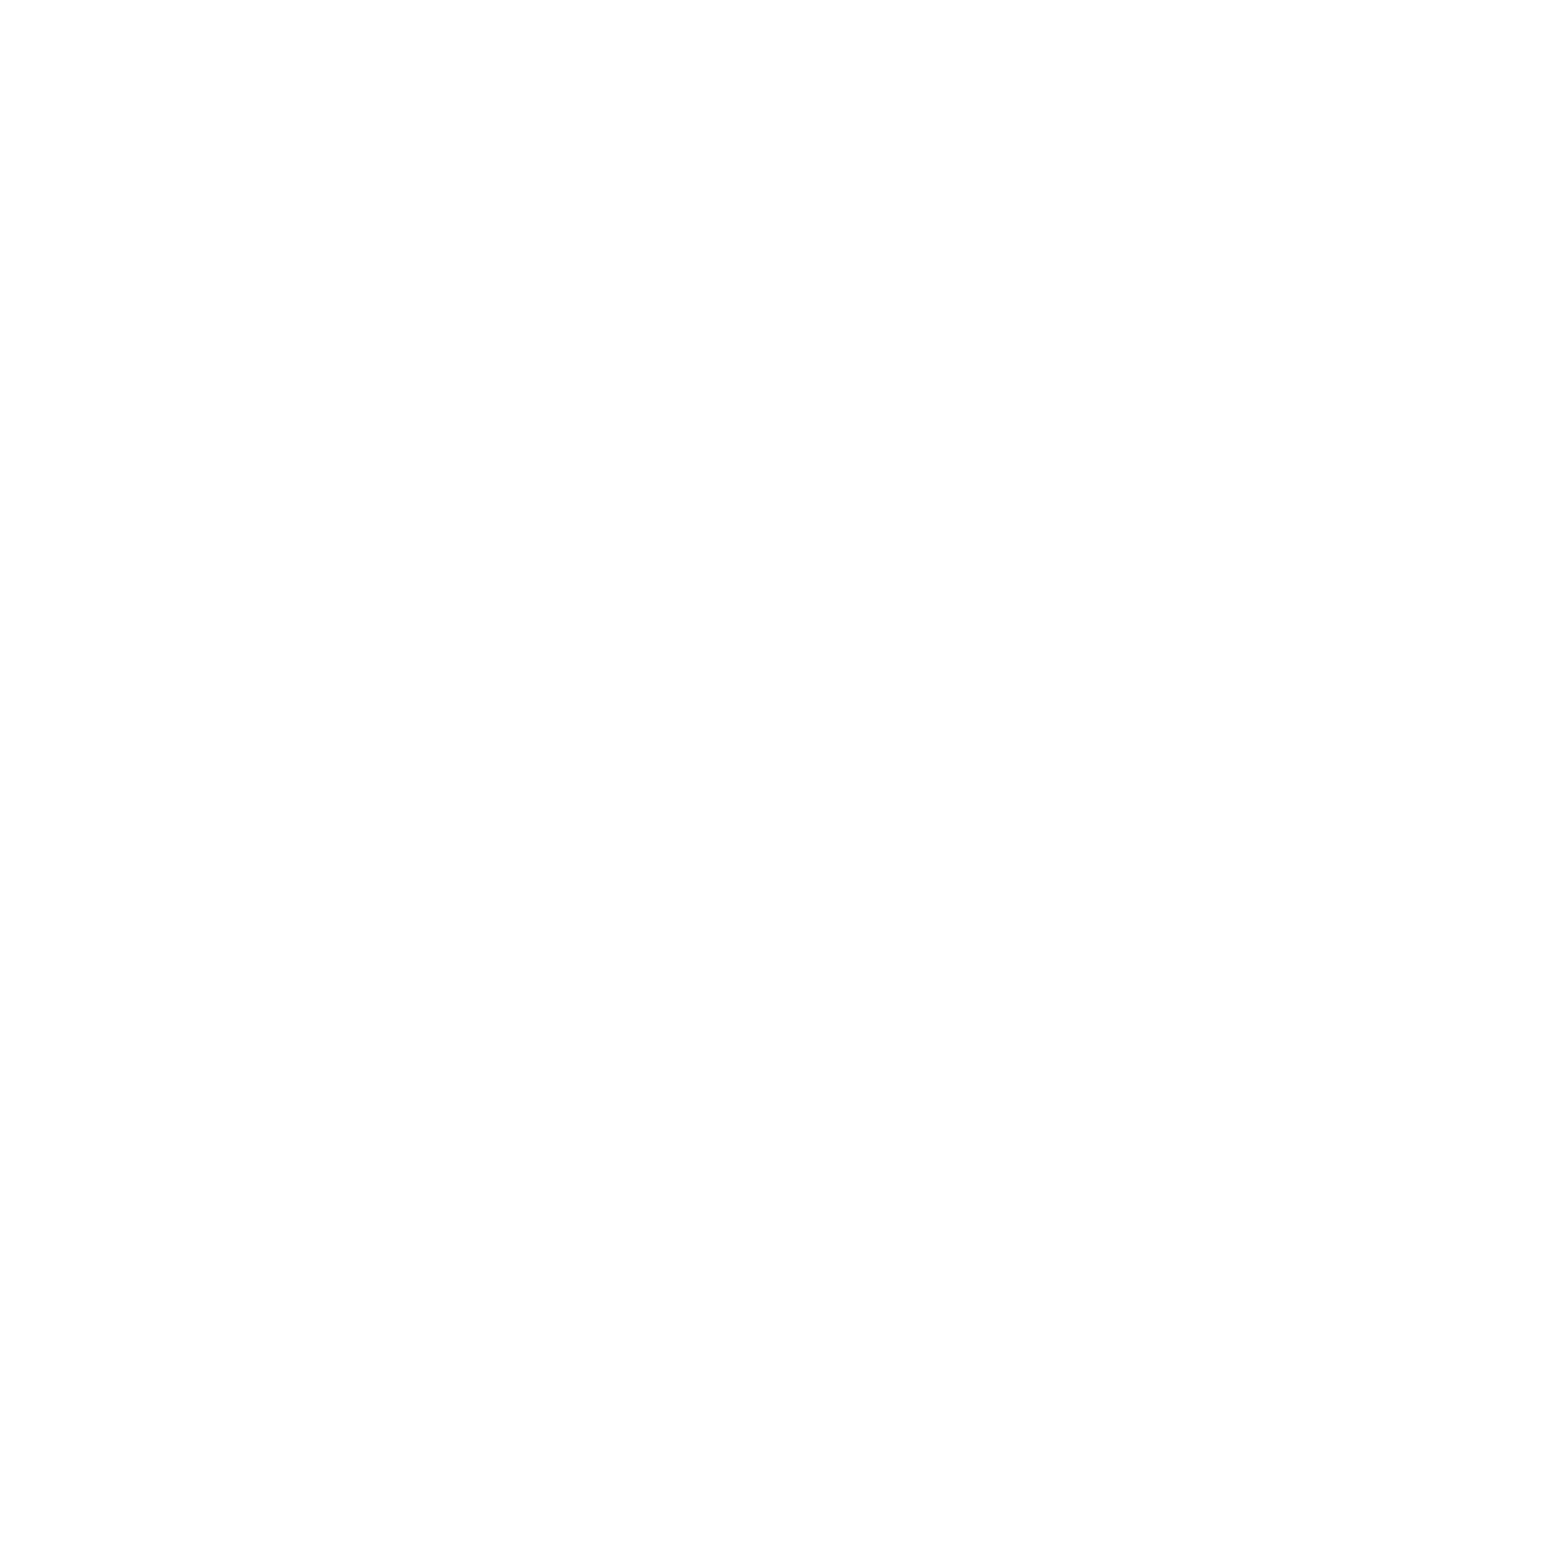

In [30]:
to_map(ds)

Next, a thresholding value is needed to detect the active fire hotspots. In order to test the thresholding method, the data is subseted into a smaller test area.

(array([[ 0.,  0.,  0., ...,  5., 12., 25.],
        [ 0.,  0.,  0., ...,  7., 13., 18.],
        [ 0.,  0.,  0., ...,  5., 13., 15.],
        ...,
        [ 0.,  0.,  0., ...,  9., 19.,  5.],
        [ 0.,  0.,  0., ...,  6., 17.,  5.],
        [ 0.,  0.,  0., ..., 13., 14.,  1.]], shape=(100, 30)),
 array([-1.47339862, -1.44484329, -1.41628796, -1.38773263, -1.35917729,
        -1.33062196, -1.30206663, -1.27351129, -1.24495596, -1.21640063,
        -1.1878453 , -1.15928996, -1.13073463, -1.1021793 , -1.07362396,
        -1.04506863, -1.0165133 , -0.98795797, -0.95940263, -0.9308473 ,
        -0.90229197, -0.87373663, -0.8451813 , -0.81662597, -0.78807064,
        -0.7595153 , -0.73095997, -0.70240464, -0.6738493 , -0.64529397,
        -0.61673864]),
 <a list of 100 BarContainer objects>)

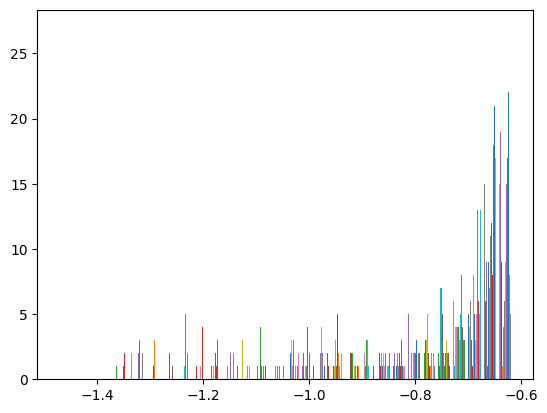

In [31]:
plt.hist(log_arr[roi_y, roi_x], bins=30)

# **Otsu's Thresholding**

Otsu's method is a simple and fast way to separate pixels into two classes, foreground and background. So it is used in this problem.



In [32]:
x = log_arr[np.isfinite(log_arr)]

thresh = np.nanpercentile(x, 99.9)
thresh


np.float64(-0.6564787982506836)

### Thermal Anomaly

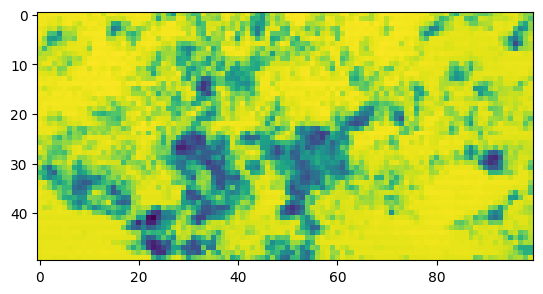

In [33]:
plt.imshow(log_arr[roi_y, roi_x])

### Thresholding Performance

As the thresholding performance of this specific value is satisfactory. It is used to filter the whole dataset.

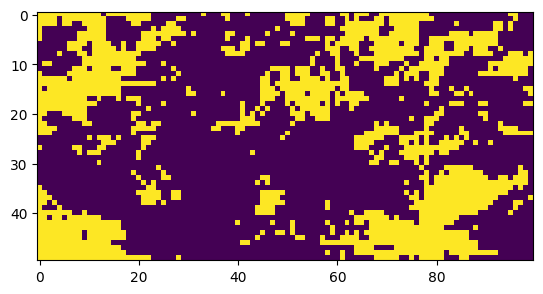

In [34]:
plt.imshow(log_arr[roi_y, roi_x] > thresh)

# **Extract Geolocations**

Checking out the data once again before extracting geolocations of the hotspots.

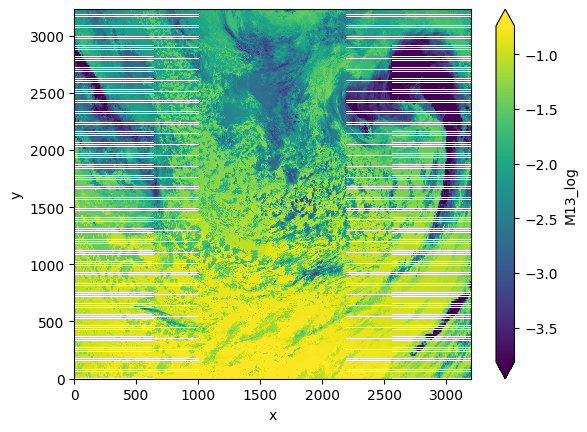

In [35]:
ds.M13_log.plot(robust=True)

The following pixels will be extracted.

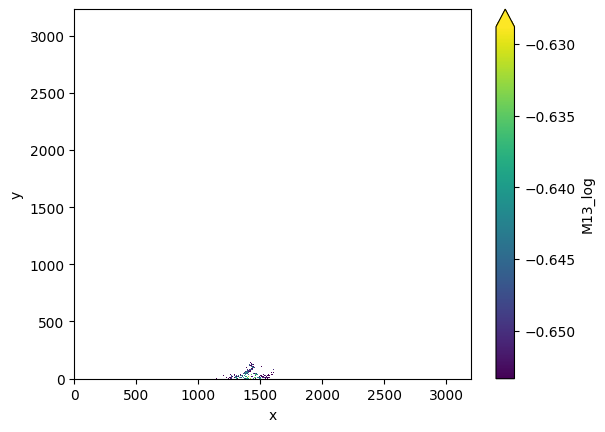

In [36]:
ds.M13_log.where(ds.M13_log > thresh).plot(robust=True)

Generate numpy arrays for M13 log value, longitude and latitude. Then putting all arrays together into a pandas dataframe.

In [37]:
M13_arr = ds.M13_log.values.flatten()

col3 = M13_arr[M13_arr > thresh]

In [38]:
lon_arr = ds.lon.values.flatten()

col1 = lon_arr[M13_arr > thresh]

In [39]:
lat_arr = ds.lat.values.flatten()

col2 = lat_arr[M13_arr > thresh]

In [40]:
hotspot_data = {'longitude': col1,'latitude': col2, 'M13_log': col3}
hotspot_df = pd.DataFrame(data=hotspot_data)

hotspot_df.head()

,longitude,latitude,M13_log
0,55.000,-33.549,-0.653
1,55.097,-33.569,-0.653
2,55.390,-33.626,-0.641
3,55.503,-33.648,-0.653
4,55.605,-33.668,-0.653


# **CSV Export**

In [41]:
hotspot_df.to_csv(r'../data/reference/fire_hotspots_v3.csv', index=False)

# **Clustering: Test Area**

Next, clustering of the extracted pixels will be performed to separate pixels into different groups. As number of groups is unknown, DBSCAN is implemented using sklearn. For first visualization, only the small test area is considered. 

In [42]:
! pip install geopandas
! pip install shapely

from shapely.geometry import mapping, Polygon, MultiPoint
import gc
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from itertools import cycle
import geopandas as gpd 

In [43]:
idx = np.where(log_arr[roi_y, roi_x] > thresh)
points = np.column_stack(idx)

In [44]:
db = DBSCAN(eps=5, min_samples=2).fit(points)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

Cluster labels for the extracted pixels in the test region.

In [45]:
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(1602,))

Visualizing pixel geolocations in different clusters to check out the performance.

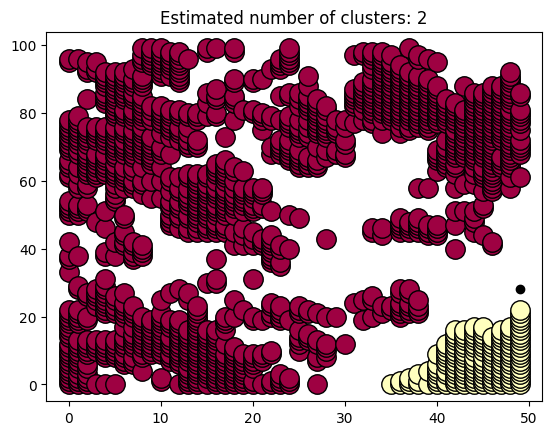

In [46]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = points[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = points[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

# **Clustering: Whole Region**

To cluster all extracted points, the csv file with point data is imported for clustering.

In [47]:
gc.collect()

3810

#### **Extracted Pixels**

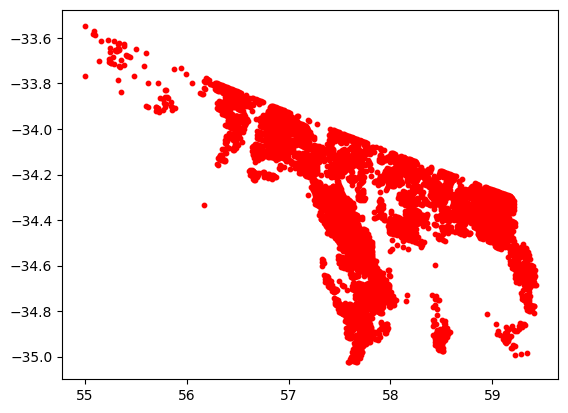

In [48]:
dataset = pd.read_csv(r'../data/reference/fire_hotspots_v3.csv')
data = dataset.iloc[:, [0, 1]].values
plt.scatter(data[:, 0], data[:, 1], s = 10, c = 'red')

Cluster groups.

In [49]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
labels = dbscan.fit_predict(data) 
np.unique(labels)

array([0])

Visualization of all clusters.

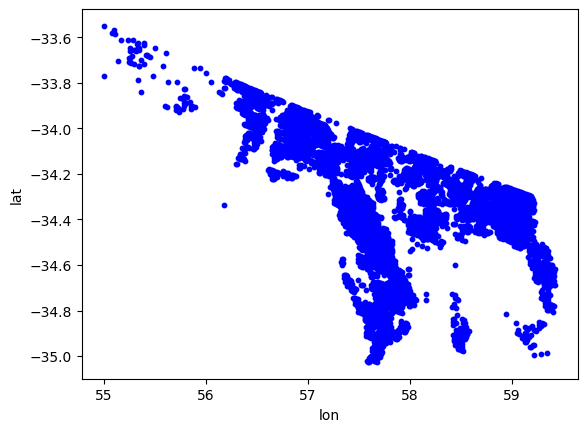

In [50]:
cycol = cycle('bgrcmk')

for i in np.unique(labels):
  plt.scatter(data[labels == i, 0], data[labels == i, 1], s = 10, c = next(cycol))

plt.xlabel('lon')
plt.ylabel('lat')
plt.show()

Here we can check out the first cluster.

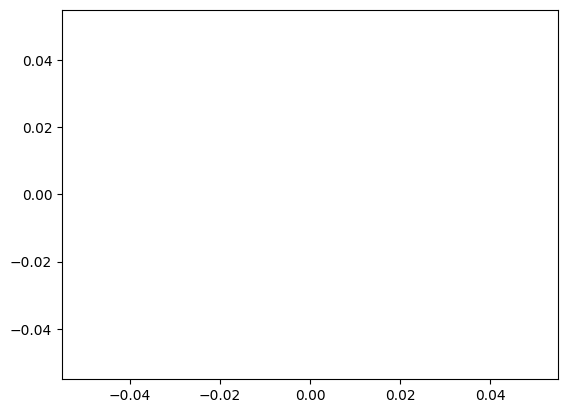

In [51]:
plt.scatter(data[labels == 1, 0],data[labels == 1, 1], color="red")

# **From Clusters to Polygons**

Now, the points are clustered, but they need to be transformed into polygon for a shapefile output. It is done by adding cluster information into the pandas dataframe, before using it with geopandas to calculate a list of polygons using convex hull implementation in the library.

In [52]:
dataset["cluster"] = pd.Series(labels)

In [53]:
dataset.head()

,longitude,latitude,M13_log,cluster
0,55.000,-33.549,-0.653,0
1,55.097,-33.569,-0.653,0
2,55.390,-33.626,-0.641,0
3,55.503,-33.648,-0.653,0
4,55.605,-33.668,-0.653,0


# **Convert Pandas into Geopandas dataframe**

In [54]:
hotspot_gdf = gpd.GeoDataFrame(
    dataset, geometry=gpd.points_from_xy(dataset.longitude, dataset.latitude)
    )

hotspot_gdf

,longitude,latitude,M13_log,cluster,geometry
0,55.000,-33.549,-0.653,0,POINT (55.00042 -33.54949)
1,55.097,-33.569,-0.653,0,POINT (55.09663 -33.56852)
2,55.390,-33.626,-0.641,0,POINT (55.38998 -33.62601)
3,55.503,-33.648,-0.653,0,POINT (55.50298 -33.64793)
4,55.605,-33.668,-0.653,0,POINT (55.60463 -33.66756)
...,...,...,...,...,...
8286,57.663,-35.023,-0.650,0,POINT (57.66258 -35.02286)
8287,57.671,-35.024,-0.650,0,POINT (57.6713 -35.02434)
8288,57.581,-35.023,-0.650,0,POINT (57.58066 -35.02293)
8289,57.589,-35.024,-0.647,0,POINT (57.58942 -35.02442)


Generate a list of polygons.

In [55]:
polygon_list = []

for i in np.unique(labels):
  cluster_rows = hotspot_gdf[hotspot_gdf.cluster == i]
  poly = cluster_rows.unary_union.convex_hull
  polygon_list.append(poly)

C:\Users\Dell PC\AppData\Local\Temp\ipykernel_29340\1989753059.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = cluster_rows.unary_union.convex_hull


In [56]:
polygon_list

[<POLYGON ((57.598 -35.026, 57.581 -35.023, 55.003 -33.769, 55 -33.549, 59.18...>]

Append the list of polygons in GeoPandas and export it into a shapefile.

In [57]:
multi_gdf = gpd.GeoDataFrame(geometry=polygon_list)
multi_gdf.to_file(filename=r'multi.shp', driver='ESRI Shapefile')

C:\Users\Dell PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


# **Functions**

In [58]:
def to_map(df,zoom=6):
    """
    Display band on an interactive map.
    Description
    ----------
    Display xarray.Dataset in a folium map with multiple basemap options.
    Parameters
    ----------
    df: xarray.Dataset
        dataset with single time step, including bands "M13".
    Returns
    -------
    map: Folium Map
        Folium map with single band displayed as images with layer control.
    """

    #error catching
    assert isinstance(df, xr.Dataset),"Input has to be a xarray.Dataset."
    
    band = df.M13_log.values
      
    #boundary of the image on the map
    min_lon = df.lon.min().values.astype(float) + 0.0
    max_lon = df.lon.max().values.astype(float) + 0.0
    min_lat = df.lat.min().values.astype(float) + 0.0
    max_lat = df.lat.max().values.astype(float) + 0.0
    
    #create basemap for folium
    basemaps = {
        'Google Satellite': folium.TileLayer(
            tiles = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
            attr = 'Google',
            name = 'Basemap: Google Satellite',
            overlay = True,
            control = True
        ),
        'Google Terrain': folium.TileLayer(
            tiles = 'https://mt1.google.com/vt/lyrs=p&x={x}&y={y}&z={z}',
            attr = 'Google',
            name = 'Basemap: Google Terrain',
            overlay = True,
            control = True
        )
    }
    
    #display layers on map
    map_ = folium.Map(location=[(min_lat+max_lat)/2, (min_lon+max_lon)/2], zoom_start = zoom)
    basemaps['Google Satellite'].add_to(map_)
    basemaps['Google Terrain'].add_to(map_)

    factor = len(df.lat)*len(df.lon)/5000000
    img = cv.resize(np.flipud(np.fliplr(band.astype('float32'))), 
                         dsize=(math.ceil(len(df.lat)/factor), 
                                math.ceil(len(df.lon)/factor)), 
                         interpolation=cv.INTER_CUBIC)

    folium.raster_layers.ImageOverlay(
        img,[[min_lat, min_lon], [max_lat, max_lon]], name='image',colormap=cm.viridis
        ).add_to(map_)
  
    folium.LayerControl().add_to(map_)
    return map_